# CWA -> MobGap walkthrough

End-to-end path:

1. set a `.cwa` path and participant metadata (dict, DataFrame, `.mat`, or `.csv`)
2. load, resample and calibrate with `omcwa` via MobGap's `mobgap.data.uos.load_cwa_as_dataset`
3. run the Mobilise-D pipeline
4. inspect the outputs

Optionally, the same steps are repeated **without** calibration so you can compare tables and cadence histograms.

## Setup

From this repository checkout (Python 3.11–3.14, `omcwa` also needs a C++17
toolchain to build from source).

**Recommended:** [uv](https://docs.astral.sh/uv/)

```bash
uv sync
```

Select the `.venv` kernel in VS Code, JupyterLab, or PyCharm after sync.

### Alternative (pip)

```bash
python -m venv .venv
source .venv/bin/activate   # Windows: .venv\Scripts\activate
python -m pip install --upgrade pip
pip install .
```

Both paths install **omcwa** and **mobgap** (UoS CWA loader on branch
[`artem/cwa-loader`](https://github.com/uos-mobgap/mobgap-plus/tree/artem/cwa-loader))
from GitHub as declared in `pyproject.toml`.

`omcwa` is installed from https://github.com/uos-mobgap/omcwa as declared in `pyproject.toml`.


In [1]:
import importlib.util
import sys


def _require(name: str) -> None:
    if importlib.util.find_spec(name) is None:
        raise ImportError(
            f"Missing {name!r}. Create the environment first with `uv sync` "
            f"(recommended) or `pip install .`, then select the .venv kernel "
            f"(Python {sys.version_info.major}.{sys.version_info.minor})."
        )


for package in ("omcwa", "mobgap", "pandas", "matplotlib"):
    _require(package)

try:
    from mobgap.data.uos import load_cwa_as_dataset, load_participant_metadata 
except ImportError as exc:
    raise ImportError(
        "mobgap is installed but lacks the UoS CWA loader (`mobgap.data.uos`). "
        "Install with `pip install 'mobgap[uos]'` or use this repo's pyproject.toml "
        "(branch artem/cwa-loader) and run `uv sync`."
    ) from exc

print("Dependencies OK.")


Dependencies OK.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from mobgap.data.uos import load_cwa_as_dataset, load_participant_metadata
from mobgap.pipeline import MobilisedPipelineHealthy

/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVers

## 1. Your inputs

Edit the next cell only.

- set `cwa_path` to your OpenMovement recording
- set `participant_metadata` to any of:
  - a dict / DataFrame / Series with **MobGap** keys
    (`height_m`, `sensor_height_m`, `cohort`; heights in metres), or
  - the same forms with **Mobilise-D** keys
    (`Height`, `SensorHeight`, `Cohort`; heights in centimetres), or
  - a path to a Mobilise-D `infoForAlgo.mat` or a `.csv` using either schema
- set `METADATA_TIME_MEASURE` when using a `.mat` file with multiple time
  measures (for example `"TimeMeasure1"`)
- set `DROP_INVALID` to control whether omconvert-invalid resampled samples are
  removed (default `True`, matching OmGUI)

`mobgap.data.uos.load_cwa_as_dataset` normalizes all of these the same way.

In [ ]:
# --- edit this cell ---

cwa_path = Path("/path/to/recording.cwa")

# Any of these work (Mobilise-D and MobGap schemas are equivalent):
participant_metadata = Path("/path/to/meta.mat")
# participant_metadata = Path("path/to/meta.csv")
# participant_metadata = {"Height": 175, "SensorHeight": 100, "Cohort": "HA"}
# participant_metadata = pd.DataFrame(
#     [{"height_m": 1.75, "sensor_height_m": 1.0, "cohort": "HA"}]
# )

# Only when participant_metadata is a .mat with multiple time measures:
# METADATA_TIME_MEASURE = "TimeMeasure1"
METADATA_TIME_MEASURE = None

recording_metadata = {"measurement_condition": "laboratory"}
RESAMPLE_HZ = 100.0

# Drop omconvert-invalid resampled samples. Set False to
# keep the full uniform timeline.
DROP_INVALID = True

# Preview plots: row index on the loaded timeline (see section 3).
# ~360_000 at 100 Hz is about one hour into this recording.
PREVIEW_START_SAMPLE = 360_000
PREVIEW_N_SAMPLES = 1_000

## 1b. Preview participant metadata

Run the next cell to check that your metadata was read correctly.
It converts Mobilise-D fields (heights in cm) to MobGap fields (heights in m)
—the same conversion `load_cwa_as_dataset` performs internally.

In [4]:
resolved_metadata = load_participant_metadata(
    participant_metadata,
    time_measure=METADATA_TIME_MEASURE,
)
display(pd.DataFrame([resolved_metadata]))

,cohort,foot_length_cm,handedness,height_m,indip_data_used,sensor_attachment_su,sensor_height_m,sensor_type_su,walking_aid_used,weight_kg
0,CP,None,right,1.585,None,Body-Worn,0.995,AX6,True,96.2


## 2. Load and calibrate

`mobgap.data.uos.load_cwa_as_dataset` calls
`load_participant_metadata`, then `omcwa.process_cwa`: decode ->
auto-calibrate -> resample -> wrap as a MobGap dataset.

By default it also drops omconvert-invalid resampled samples
(`drop_invalid=True`, matching OmGUI analytics). These are usually startup gaps
before the sensor stream is usable. Recording metadata includes
`cwa_invalid_samples` (count before dropping) and `cwa_invalid_samples_dropped`.
Set `drop_invalid=False` in the inputs cell to keep the full uniform timeline.

Sensor columns use MobGap units: acceleration in m/s^2, gyroscope in deg/s.

In [5]:
dataset = load_cwa_as_dataset(
    cwa_path,
    participant_metadata,
    recording_metadata=recording_metadata,
    resample_hz=RESAMPLE_HZ,
    calibrate=True,
    drop_invalid=DROP_INVALID,
    include_time_index=True,
    metadata_time_measure=METADATA_TIME_MEASURE,
)

datapoint = dataset[0]
samples = datapoint.data_ss.copy()
samples.insert(0, "timestamp", samples.index)

print(f"sampling rate: {datapoint.sampling_rate_hz} Hz")
print(f"samples:       {len(samples)}")
print(f"calibration:   {datapoint.recording_metadata.get('cwa_calibration_success')}")
print(
    "invalid total:",
    datapoint.recording_metadata.get("cwa_invalid_samples"),
)
print(
    "invalid dropped:",
    datapoint.recording_metadata.get("cwa_invalid_samples_dropped"),
)
display(pd.DataFrame([datapoint.participant_metadata]))

preview = samples.iloc[
    PREVIEW_START_SAMPLE : PREVIEW_START_SAMPLE + PREVIEW_N_SAMPLES
]
display(preview.head(10))

sampling rate: 100.0 Hz
samples:       75420336
calibration:   True
invalid total: 514
invalid dropped: 514


,cohort,foot_length_cm,handedness,height_m,indip_data_used,sensor_attachment_su,sensor_height_m,sensor_type_su,walking_aid_used,weight_kg
0,CP,None,right,1.585,None,Body-Worn,0.995,AX6,True,96.2


,timestamp,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
time,,,,,,,
1.773450e+09,1.773450e+09,-0.085960,-9.802822,-0.393560,-0.476577,-0.886934,-0.801902
1.773450e+09,1.773450e+09,-0.070918,-9.804103,-0.404323,-0.384712,-0.845896,-0.793457
1.773450e+09,1.773450e+09,-0.072286,-9.803226,-0.414352,-0.386169,-0.693719,-0.800448
1.773450e+09,1.773450e+09,-0.065222,-9.807478,-0.409569,-0.442459,-0.445081,-0.764621
1.773450e+09,1.773450e+09,-0.061241,-9.800994,-0.395144,-0.397707,-0.290912,-0.731933
1.773450e+09,1.773450e+09,-0.077889,-9.795514,-0.410097,-0.358513,-0.190944,-0.709740
1.773450e+09,1.773450e+09,-0.074572,-9.812653,-0.426962,-0.373946,-0.198794,-0.632921
1.773450e+09,1.773450e+09,-0.078435,-9.810572,-0.418313,-0.326663,-0.259422,-0.610916
1.773450e+09,1.773450e+09,-0.076545,-9.796295,-0.400341,-0.338438,-0.425487,-0.578002


## 3. Peek at the acceleration

Plot a short window of `acc_x` from later in the recording (not the file
start). Adjust `PREVIEW_START_SAMPLE` / `PREVIEW_N_SAMPLES` in the inputs cell.

`PREVIEW_START_SAMPLE` is a row index on the loaded timeline (after optional
invalid-sample dropping), not a raw omconvert sample index.

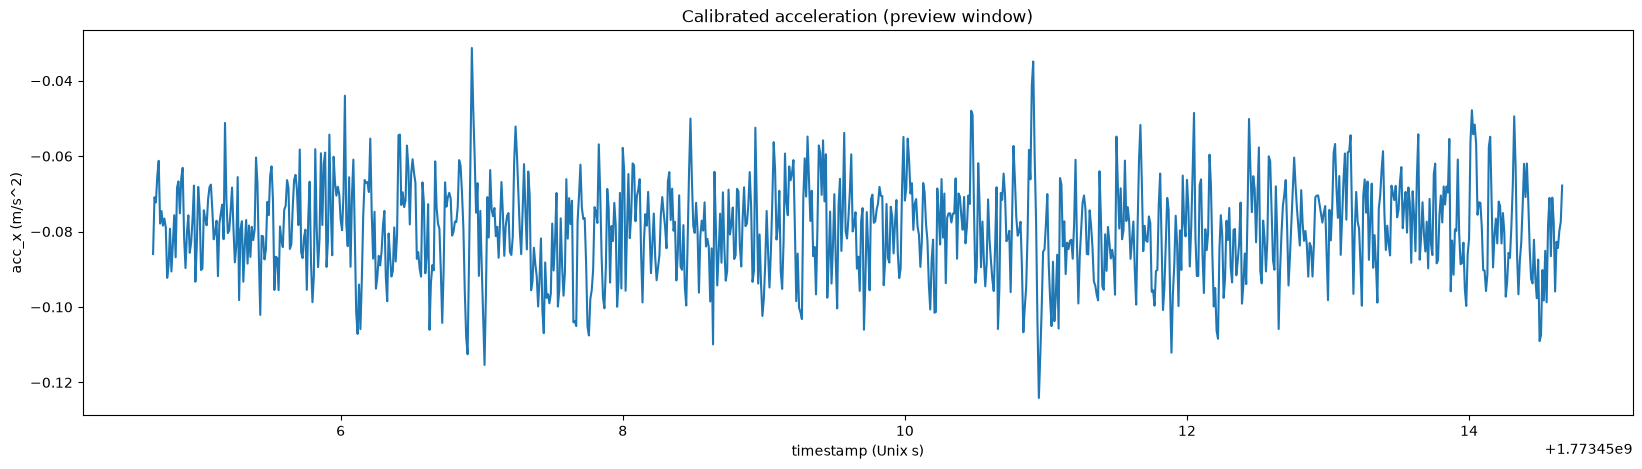

In [6]:
start_id = PREVIEW_START_SAMPLE
end_id = PREVIEW_START_SAMPLE + PREVIEW_N_SAMPLES

samples_to_plot = samples.iloc[start_id:end_id]

plt.figure(figsize=(20, 5))
plt.plot(samples_to_plot["timestamp"], samples_to_plot["acc_x"])
plt.xlabel("timestamp (Unix s)")
plt.ylabel("acc_x (m/s^2)")
plt.title("Calibrated acceleration (preview window)")
plt.show()

## 4. Run the MobGap pipeline

This uses the healthy Mobilise-D preset (`MobilisedPipelineHealthy`),
matching the tutorial. For PD / MS / PFF cohorts, switch to
`MobilisedPipelineImpaired`.

In [7]:
pipeline = MobilisedPipelineHealthy(dmo_thresholds=None).safe_run(datapoint)
print("Pipeline finished running!")

/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.14/site-packages/mobgap/pipeline/_mobilised_pipeline.py:226: UserWarning: The provided datapoint has data of a participant with the cohort CP is not part of the recommended cohorts for this pipeline MobilisedPipelineHealthy.
Recommended cohorts are ('HA', 'COPD', 'CHF')
  warnings.warn(


Pipeline finished running!


## 5. Outputs

Aggregated DMOs across walking bouts, then the first few per-bout rows,
and a simple cadence histogram.

In [8]:
display(pipeline.aggregated_parameters_)

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,1147,280.701333,22198,8.44,27.668,1.423283,80.369174,1.292637,0.140981,0.199687,...,100,0.620316,0.916537,79.622711,1.317608,0.942751,94.48726,0.437429,0.342329,27


In [9]:
display(pipeline.per_wb_parameters_.head(5))

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,3437012,3437920,11,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.08,13,1.250909,91.399206,0.625078,0.481298
1,3439022,3439580,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.58,6,1.620000,99.104180,0.834698,0.666378
2,3440042,3441042,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",10.00,12,1.261111,85.290464,0.984330,0.693884
3,3441485,3442130,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",6.45,8,1.441667,85.947600,0.678911,0.481628
4,3608530,3609268,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.38,11,0.871111,78.903560,0.524278,0.348345


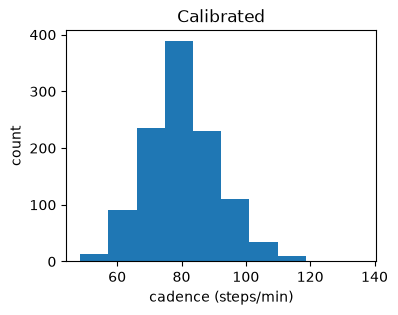

In [10]:
plt.figure(figsize=(4, 3))
plt.hist(pipeline.per_wb_parameters_["cadence_spm"], bins=10)
plt.xlabel("cadence (steps/min)")
plt.ylabel("count")
plt.title("Calibrated")
plt.show()

---

## Optional: uncalibrated run

Same load -> pipeline -> outputs path, but with `calibrate=False`.
These cells are collapsed by default. Expand them if you want the comparison.

In [11]:
dataset_uncal = load_cwa_as_dataset(
    cwa_path,
    participant_metadata,
    recording_metadata=recording_metadata,
    resample_hz=RESAMPLE_HZ,
    calibrate=False,
    drop_invalid=DROP_INVALID,
    include_time_index=True,
    metadata_time_measure=METADATA_TIME_MEASURE,
)

datapoint_uncal = dataset_uncal[0]
samples_uncal = datapoint_uncal.data_ss.copy()
samples_uncal.insert(0, "timestamp", samples_uncal.index)

print(f"sampling rate: {datapoint_uncal.sampling_rate_hz} Hz")
print(f"samples:       {len(samples_uncal)}")
print(f"calibration:   {datapoint_uncal.recording_metadata.get('cwa_calibration_success')}")
print(
    "invalid total:",
    datapoint_uncal.recording_metadata.get("cwa_invalid_samples"),
)
print(
    "invalid dropped:",
    datapoint_uncal.recording_metadata.get("cwa_invalid_samples_dropped"),
)
preview_uncal = samples_uncal.iloc[
    PREVIEW_START_SAMPLE : PREVIEW_START_SAMPLE + PREVIEW_N_SAMPLES
]
display(preview_uncal.head(10))

sampling rate: 100.0 Hz
samples:       75420336
calibration:   True
invalid total: 514
invalid dropped: 514


,timestamp,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
time,,,,,,,
1.773450e+09,1.773450e+09,-0.518388,-9.998570,-0.117129,-0.476577,-0.886934,-0.801902
1.773450e+09,1.773450e+09,-0.503231,-9.999855,-0.127870,-0.384712,-0.845896,-0.793457
1.773450e+09,1.773450e+09,-0.504610,-9.998975,-0.137879,-0.386169,-0.693719,-0.800448
1.773450e+09,1.773450e+09,-0.497492,-10.003238,-0.133105,-0.442459,-0.445081,-0.764621
1.773450e+09,1.773450e+09,-0.493481,-9.996736,-0.118710,-0.397707,-0.290912,-0.731933
1.773450e+09,1.773450e+09,-0.510256,-9.991241,-0.133633,-0.358513,-0.190944,-0.709740
1.773450e+09,1.773450e+09,-0.506914,-10.008428,-0.150463,-0.373946,-0.198794,-0.632921
1.773450e+09,1.773450e+09,-0.510806,-10.006341,-0.141832,-0.326663,-0.259422,-0.610916
1.773450e+09,1.773450e+09,-0.508902,-9.992025,-0.123896,-0.338438,-0.425487,-0.578002


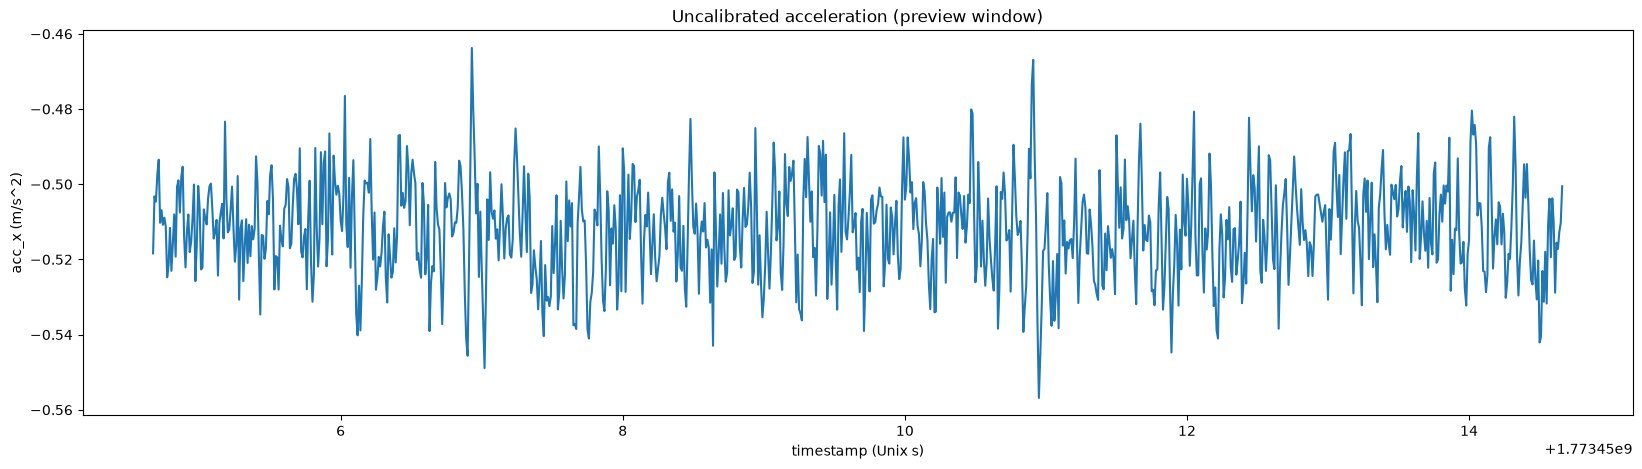

In [12]:
samples_to_plot = samples_uncal.iloc[start_id:end_id]

plt.figure(figsize=(20, 5))
plt.plot(samples_to_plot["timestamp"], samples_to_plot["acc_x"])
plt.xlabel("timestamp (Unix s)")
plt.ylabel("acc_x (m/s^2)")
plt.title("Uncalibrated acceleration (preview window)")
plt.show()

/Users/artem/Work/n8-mobgap/mobilise-d_mobgap_tutorial/.venv/lib/python3.14/site-packages/mobgap/pipeline/_mobilised_pipeline.py:226: UserWarning: The provided datapoint has data of a participant with the cohort CP is not part of the recommended cohorts for this pipeline MobilisedPipelineHealthy.
Recommended cohorts are ('HA', 'COPD', 'CHF')
  warnings.warn(


Uncalibrated pipeline finished!


,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,1148,276.636833,21885,8.305,26.744,1.427473,79.994214,1.291372,0.141902,0.200811,...,96,0.618687,0.919603,79.259258,1.318726,0.956155,93.861916,0.440603,0.349506,27


,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,3437012,3437920,11,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.08,13,1.250909,90.055537,0.627455,0.474877
1,3440042,3441042,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",10.00,12,1.261111,83.887187,0.988045,0.687824
2,3441485,3442130,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",6.45,8,1.441667,76.144988,0.681490,0.429554
3,3608530,3609268,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.38,11,0.871111,78.447983,0.526275,0.348079
4,3610405,3611215,7,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",8.10,10,1.418571,85.525866,0.575223,0.410628


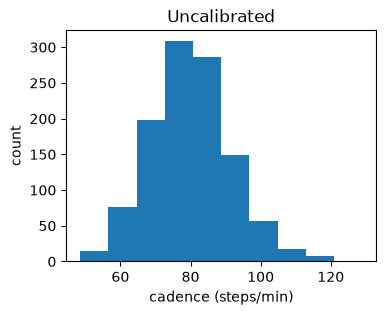

In [13]:
pipeline_uncal = MobilisedPipelineHealthy(dmo_thresholds=None).safe_run(datapoint_uncal)
print("Uncalibrated pipeline finished!")

display(pipeline_uncal.aggregated_parameters_)
display(pipeline_uncal.per_wb_parameters_.head(5))

plt.figure(figsize=(4, 3))
plt.hist(pipeline_uncal.per_wb_parameters_["cadence_spm"], bins=10)
plt.xlabel("cadence (steps/min)")
plt.ylabel("count")
plt.title("Uncalibrated")
plt.show()

## Compare calibrated vs uncalibrated

Overlay the first-window `acc_x` trace, then compare tables and cadence
histograms side by side.

Run the optional uncalibrated cells above first.

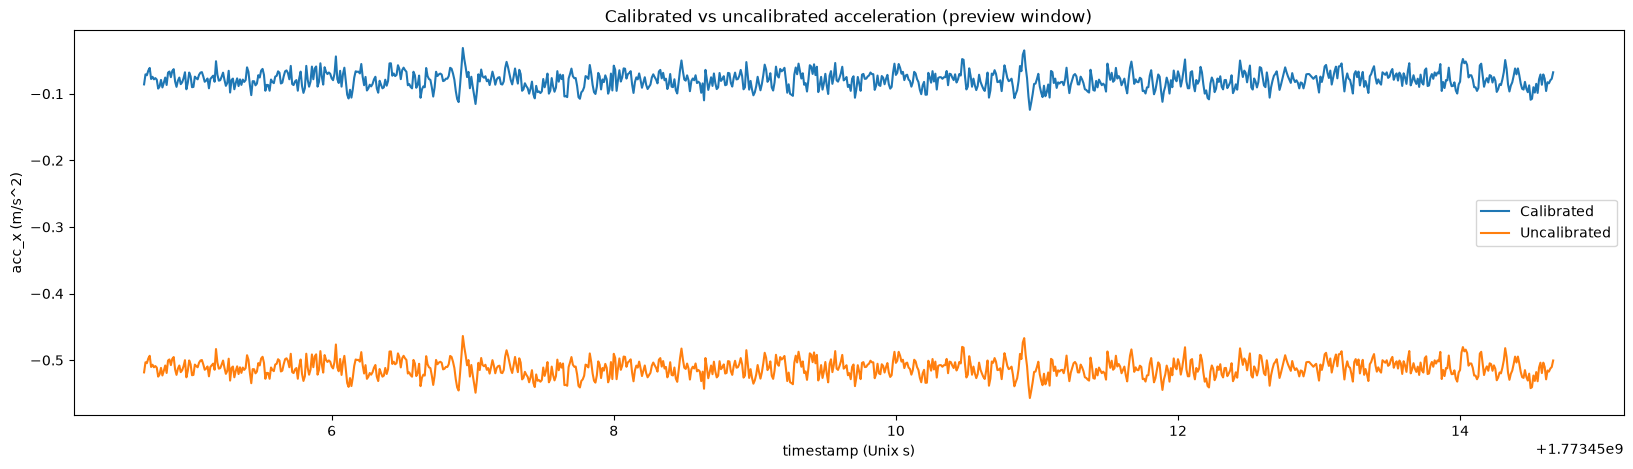

In [14]:
window_cal = samples.iloc[start_id:end_id]
window_uncal = samples_uncal.iloc[start_id:end_id]

plt.figure(figsize=(20, 5))
plt.plot(window_cal["timestamp"], window_cal["acc_x"], label="Calibrated", color="C0")
plt.plot(window_uncal["timestamp"], window_uncal["acc_x"], label="Uncalibrated", color="C1")
plt.xlabel("timestamp (Unix s)")
plt.ylabel("acc_x (m/s^2)")
plt.title("Calibrated vs uncalibrated acceleration (preview window)")
plt.legend()
plt.show()

In [15]:
print("Calibrated - first 5 walking bouts")
display(pipeline.per_wb_parameters_.head(5))

print("Uncalibrated - first 5 walking bouts")
display(pipeline_uncal.per_wb_parameters_.head(5))

Calibrated - first 5 walking bouts


,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,3437012,3437920,11,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.08,13,1.250909,91.399206,0.625078,0.481298
1,3439022,3439580,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.58,6,1.620000,99.104180,0.834698,0.666378
2,3440042,3441042,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",10.00,12,1.261111,85.290464,0.984330,0.693884
3,3441485,3442130,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",6.45,8,1.441667,85.947600,0.678911,0.481628
4,3608530,3609268,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.38,11,0.871111,78.903560,0.524278,0.348345


Uncalibrated - first 5 walking bouts


,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,3437012,3437920,11,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.08,13,1.250909,90.055537,0.627455,0.474877
1,3440042,3441042,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",10.00,12,1.261111,83.887187,0.988045,0.687824
2,3441485,3442130,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",6.45,8,1.441667,76.144988,0.681490,0.429554
3,3608530,3609268,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.38,11,0.871111,78.447983,0.526275,0.348079
4,3610405,3611215,7,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",8.10,10,1.418571,85.525866,0.575223,0.410628


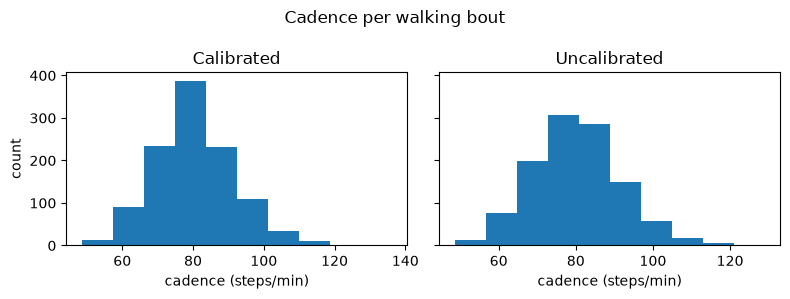

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

axes[0].hist(pipeline.per_wb_parameters_["cadence_spm"], bins=10)
axes[0].set_title("Calibrated")
axes[0].set_xlabel("cadence (steps/min)")
axes[0].set_ylabel("count")

axes[1].hist(pipeline_uncal.per_wb_parameters_["cadence_spm"], bins=10)
axes[1].set_title("Uncalibrated")
axes[1].set_xlabel("cadence (steps/min)")

fig.suptitle("Cadence per walking bout")
fig.tight_layout()
plt.show()

In [17]:
print("Calibrated aggregated DMOs")
display(pipeline.aggregated_parameters_)

print("Uncalibrated aggregated DMOs")
display(pipeline_uncal.aggregated_parameters_)

Calibrated aggregated DMOs


,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,1147,280.701333,22198,8.44,27.668,1.423283,80.369174,1.292637,0.140981,0.199687,...,100,0.620316,0.916537,79.622711,1.317608,0.942751,94.48726,0.437429,0.342329,27


Uncalibrated aggregated DMOs


,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,1148,276.636833,21885,8.305,26.744,1.427473,79.994214,1.291372,0.141902,0.200811,...,96,0.618687,0.919603,79.259258,1.318726,0.956155,93.861916,0.440603,0.349506,27
